# EV County-Level PCA and Clustering

This notebook applies Principal Component Analysis (PCA) and K-Means / Hierarchical clustering
to the cleaned, log-transformed, and standardized county-level EV dataset.

**Pipeline:**
1. Load the scaled data (`county_scaled.csv`)
2. Select features for PCA (log-transformed count features + behavioral features)
3. PCA — scree plot, loadings, biplot
4. K-Means clustering — elbow method + silhouette scores to choose k
5. Hierarchical clustering — dendrogram
6. Profile and interpret each cluster
7. Save outputs

## 1. Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

RANDOM_STATE = 42

## 2. Load Data

In [3]:
# Load the scaled county-level dataset (output of EV_project_normalization.ipynb)
county_scaled = pd.read_csv("county_scaled.csv")

print("Dataset shape:", county_scaled.shape)
print("\nColumns:")
print(county_scaled.columns.tolist())
print("\nFirst 5 rows:")
display(county_scaled.head())

Dataset shape: (39, 25)

Columns:
['county', 'total_EV_count', 'BEV_count', 'PHEV_count', 'avg_model_year', 'avg_electric_range', 'avg_vehicle_age', 'percent_BEV', 'percent_PHEV', 'BEV_to_PHEV_ratio', 'median_income_2025', 'total_chargers', 'level1_chargers', 'level2_chargers', 'dc_fast_chargers', 'fast_charger_share', 'chargers_per_1000_EV', 'total_EV_count_log', 'BEV_count_log', 'PHEV_count_log', 'total_chargers_log', 'level1_chargers_log', 'level2_chargers_log', 'dc_fast_chargers_log', 'chargers_per_1000_EV_log']

First 5 rows:


,county,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,total_chargers,level1_chargers,level2_chargers,dc_fast_chargers,fast_charger_share,chargers_per_1000_EV,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
0,ADAMS,-0.304028,-0.293785,-0.343275,0.351146,0.321535,-0.351146,0.167054,-0.164494,-0.056726,-0.943417,-0.284265,-0.185346,-0.283009,-0.281631,2.701390,1.016734,-1.114216,-1.056557,-1.189832,-0.650199,-0.354030,-1.817486,0.251486,1.534355
1,ASOTIN,-0.303403,-0.293637,-0.340779,-0.335187,-0.796852,0.335187,-0.587885,0.589688,-0.825894,-0.531097,-0.302321,-0.185346,-0.277127,-0.463012,-0.849210,-0.369807,-1.047830,-1.038530,-1.017391,-1.403685,-0.354030,-1.146074,-1.099162,-0.357901
2,BENTON,-0.151110,-0.162655,-0.105280,0.102907,0.097750,-0.102907,-0.033466,0.035825,-0.291918,0.769852,-0.191406,-0.185346,-0.194781,-0.160711,0.334323,-0.468077,0.649723,0.626235,0.710560,0.304856,-0.354030,0.281179,0.527180,-0.688372
3,CHELAN,-0.238788,-0.228926,-0.276742,0.693473,1.306427,-0.693473,1.161181,-1.157625,1.672837,0.035469,-0.101126,0.283529,-0.127139,0.081131,0.349117,0.243146,0.249647,0.307819,0.080535,0.658957,2.363072,0.620363,0.855439,0.797796
4,CLALLAM,-0.234705,-0.235840,-0.229491,-1.035965,-0.557642,1.035965,-0.215862,0.218038,-0.484569,-0.368438,-0.132080,-0.185346,-0.150667,0.000517,0.351728,0.056492,0.277632,0.257791,0.340796,0.558610,-0.354030,0.522370,0.765017,0.537893


## 3. Feature Selection for PCA

We use the **log-transformed** versions of count features (already scaled) together with
the behavioral/ratio features. We drop the raw count columns to avoid redundancy — the
log versions are better behaved and were the ones intended for downstream analysis.

In [4]:
county_col = "county"

# Log-transformed count features (scaled)
log_features = [
    "total_EV_count_log",
    "BEV_count_log",
    "PHEV_count_log",
    "total_chargers_log",
    "level1_chargers_log",
    "level2_chargers_log",
    "dc_fast_chargers_log",
    "chargers_per_1000_EV_log",
]

# Behavioral / ratio features (scaled)
behavioral_features = [
    "percent_BEV",
    "percent_PHEV",
    "BEV_to_PHEV_ratio",
    "avg_model_year",
    "avg_vehicle_age",
    "avg_electric_range",
    "median_income_2025",
    "fast_charger_share",
]

pca_features = log_features + behavioral_features

# Verify all features exist
missing = [f for f in pca_features if f not in county_scaled.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

print(f"Using {len(pca_features)} features for PCA:")
print(pca_features)

# Build the feature matrix and keep county labels
county_labels = county_scaled[county_col].values
X = county_scaled[pca_features].values

print(f"\nFeature matrix shape: {X.shape}")

Using 16 features for PCA:
['total_EV_count_log', 'BEV_count_log', 'PHEV_count_log', 'total_chargers_log', 'level1_chargers_log', 'level2_chargers_log', 'dc_fast_chargers_log', 'chargers_per_1000_EV_log', 'percent_BEV', 'percent_PHEV', 'BEV_to_PHEV_ratio', 'avg_model_year', 'avg_vehicle_age', 'avg_electric_range', 'median_income_2025', 'fast_charger_share']

Feature matrix shape: (39, 16)


We are using 16 different measurements about each county — things like how many EVs and chargers they have, what percentage are fully electric vs plug-in hybrid, how new the cars are, how far they can go on a charge, the average income, and what share of chargers are fast chargers. We have data for 39 counties across these 16 features.

## 4. Principal Component Analysis (PCA)

### 4.1 Fit PCA and Scree Plot

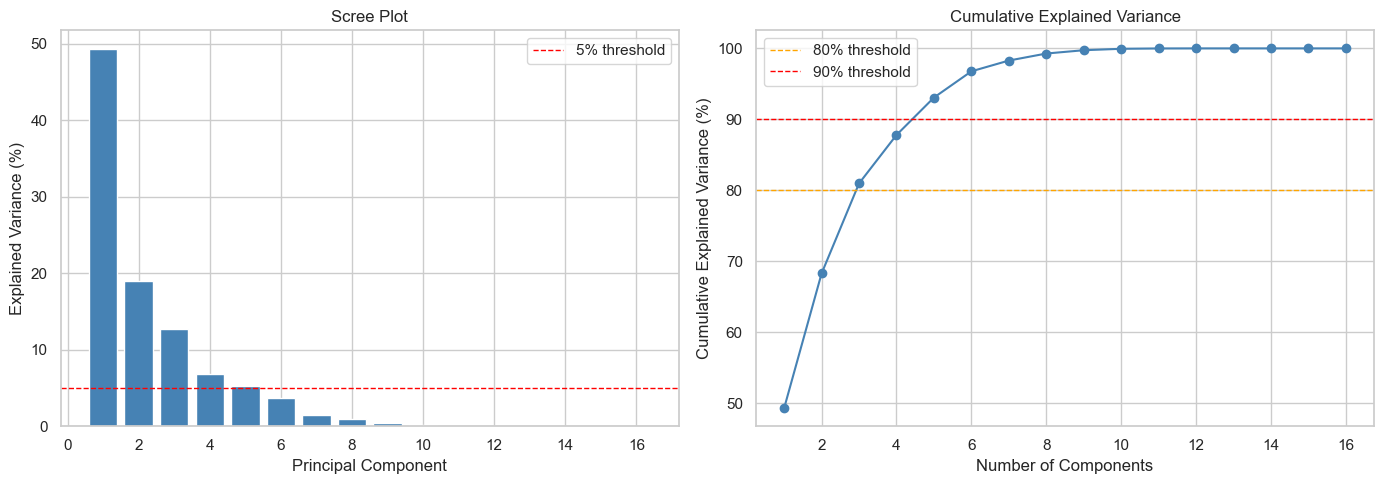


Variance explained by each principal component:


,PC,Explained Variance (%),Cumulative Variance (%)
0,PC1,49.30,49.30
1,PC2,18.98,68.28
2,PC3,12.69,80.97
3,PC4,6.83,87.80
4,PC5,5.27,93.07
5,PC6,3.70,96.77
6,PC7,1.52,98.29
7,PC8,0.99,99.28
8,PC9,0.47,99.74
9,PC10,0.20,99.94



Components needed for 80% variance: 3
Components needed for 90% variance: 5


In [6]:
# Fit full PCA to see all variance explained
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual explained variance (scree)
axes[0].bar(range(1, len(explained_var) + 1), explained_var * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")
axes[0].axhline(y=5, color='red', linestyle='--', linewidth=1, label='5% threshold')
axes[0].legend()

# Right: cumulative explained variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, 'o-', color='steelblue')
axes[1].axhline(y=80, color='orange', linestyle='--', linewidth=1, label='80% threshold')
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=1, label='90% threshold')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print variance table
variance_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained Variance (%)": (explained_var * 100).round(2),
    "Cumulative Variance (%)": (cumulative_var * 100).round(2),
})
print("\nVariance explained by each principal component:")
display(variance_table.head(10))

# How many components to reach 80% and 90%?
n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"\nComponents needed for 80% variance: {n_80}")
print(f"Components needed for 90% variance: {n_90}")

**Scree Plot (left):** The first principal component alone explains nearly 50% of the variance in the data — meaning one single summary captures half of everything going on across all 39 counties. The second component adds another ~19%, and the third ~13%. After the 5th component, each additional one adds very little (below the 5% red line), so they are not very useful.

**Cumulative Variance (right):** Just 3 components get us past 80% and 4 components get us to nearly 90%. This means we can reduce our 16 original measurements down to just 3–4 summary numbers while still capturing most of the meaningful patterns in the data. Everything beyond component 8 adds almost nothing new.

The data has a strong dominant pattern (PC1) that likely reflects overall county size and EV adoption level. We only need 3 to 4 components to get a good summary of the data, which makes clustering much more manageable.

PC1 alone captures 49.3% of all the variation — nearly half the story in just one number. Adding PC2 brings us to 68.3%, and by PC3 we cross the 80% mark (80.97%). PC4 gets us to 87.8% and PC5 to 93%.
After PC5, the remaining components each add less than 4%, and by PC8 we are already at 99.3% — meaning the last 8 components combined explain less than 1% of the data.

To capture 80% of the patterns in our county EV data, we only need 3 components instead of the original 16 measurements. To get to 90%, we need just 5 components. This is a huge reduction — we went from 16 numbers per county down to 3–5 summary scores while still keeping most of the meaningful information. We chose to work with 3 components going forward as a good balance between simplicity and information retained.

### 4.2 Fit Reduced PCA (chosen number of components)

In [7]:
# Choose number of components that explains ~80% variance
n_components = n_80

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print(f"Reduced PCA shape: {X_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

# Create PCA scores DataFrame
pc_cols = [f"PC{i+1}" for i in range(n_components)]
pca_scores = pd.DataFrame(X_pca, columns=pc_cols)
pca_scores.insert(0, county_col, county_labels)

print("\nPCA scores (first 5 rows):")
display(pca_scores.head())

Reduced PCA shape: (39, 3)
Total variance explained: 81.0%

PCA scores (first 5 rows):


,county,PC1,PC2,PC3
0,ADAMS,-1.833443,2.401609,2.138565
1,ASOTIN,-3.126324,0.052020,-0.844782
2,BENTON,1.086439,-0.807701,0.228506
3,CHELAN,2.834057,1.761989,-0.007681
4,CLALLAM,0.007377,-1.466995,0.773403


We successfully reduced our data from 16 features down to just 3 summary scores (PC1, PC2, PC3) for each of the 39 counties, while retaining 81% of the original information.
Each row is now a county represented by 3 numbers instead of 16. For example:

Adams County has a negative PC1 score (−1.83), meaning it is below average on the main EV adoption dimension, but has high PC2 (2.40) and PC3 (2.14) scores
Asotin County has the most negative PC1 (−3.13), suggesting it is one of the least EV-adopted counties, with near-zero PC2 and negative PC3
Chelan County has a high positive PC1 (2.83), placing it among the more EV-forward countie

### 4.3 PCA Loadings Heatmap

PCA Loadings (feature contributions to each PC):


,PC1,PC2,PC3
total_EV_count_log,0.327,-0.194,0.027
BEV_count_log,0.333,-0.166,0.015
PHEV_count_log,0.312,-0.239,0.057
total_chargers_log,0.319,-0.172,0.196
level1_chargers_log,0.199,-0.065,-0.066
level2_chargers_log,0.313,-0.199,0.021
dc_fast_chargers_log,0.258,-0.101,0.370
chargers_per_1000_EV_log,-0.018,0.251,0.429
percent_BEV,0.277,0.288,-0.193
percent_PHEV,-0.277,-0.289,0.193


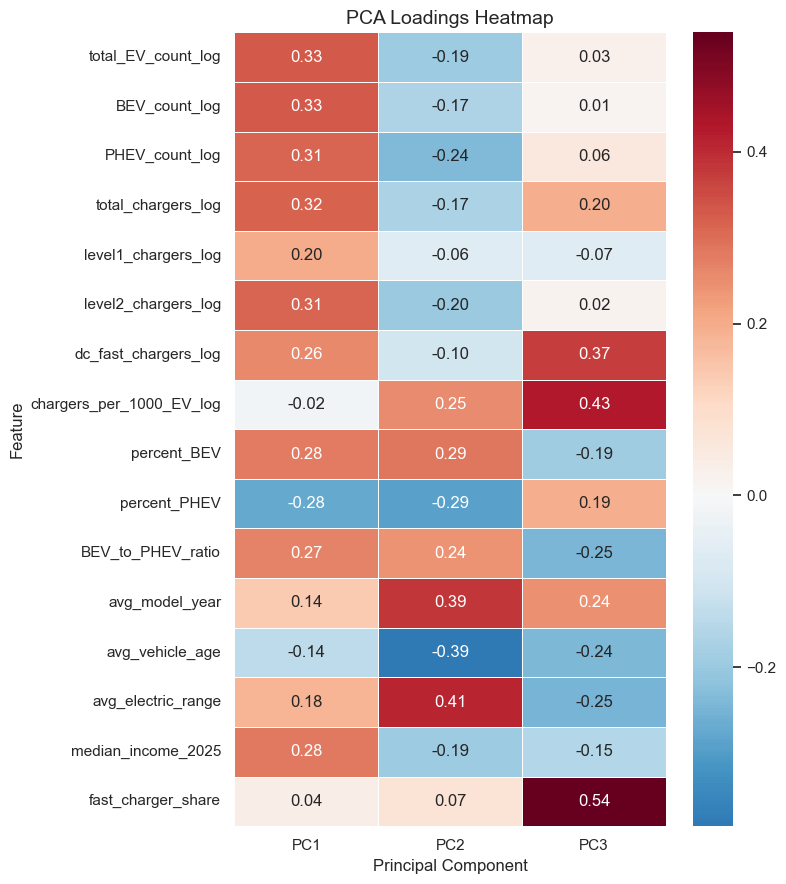

In [9]:
# Build loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=pc_cols
)

print("PCA Loadings (feature contributions to each PC):")
display(loadings.round(3))

# Heatmap of loadings
fig, ax = plt.subplots(figsize=(max(8, n_components * 1.5), 9))
sns.heatmap(
    loadings,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("PCA Loadings Heatmap", fontsize=14)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### 4.4 Biplot (PC1 vs PC2)

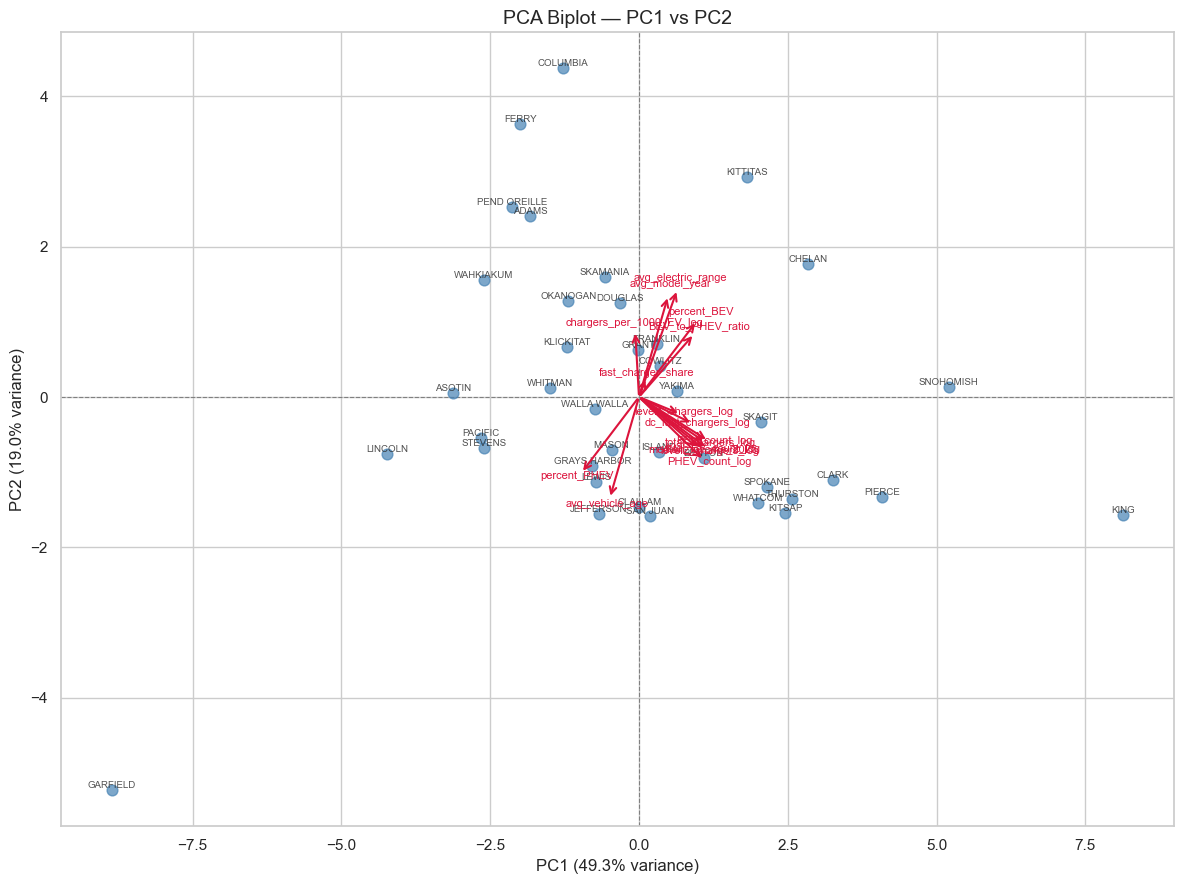

In [10]:
def biplot(scores, loadings, county_names, pc_x=0, pc_y=1, scale=3.5, figsize=(12, 9)):
    """Plot PCA biplot with county labels and loading arrows."""
    fig, ax = plt.subplots(figsize=figsize)

    # Scatter county scores
    ax.scatter(scores[:, pc_x], scores[:, pc_y], alpha=0.7, s=60, color='steelblue', zorder=3)

    for i, name in enumerate(county_names):
        ax.annotate(name, (scores[i, pc_x], scores[i, pc_y]),
                    fontsize=7, alpha=0.8, ha='center', va='bottom')

    # Draw loading arrows
    for j, feat in enumerate(loadings.index):
        lx = loadings.iloc[j, pc_x] * scale
        ly = loadings.iloc[j, pc_y] * scale
        ax.annotate("", xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5))
        ax.text(lx * 1.08, ly * 1.08, feat, color='crimson', fontsize=8, ha='center')

    pct_x = pca.explained_variance_ratio_[pc_x] * 100
    pct_y = pca.explained_variance_ratio_[pc_y] * 100
    ax.set_xlabel(f"PC{pc_x+1} ({pct_x:.1f}% variance)", fontsize=12)
    ax.set_ylabel(f"PC{pc_y+1} ({pct_y:.1f}% variance)", fontsize=12)
    ax.set_title(f"PCA Biplot — PC{pc_x+1} vs PC{pc_y+1}", fontsize=14)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    return fig

fig = biplot(X_pca, loadings, county_labels)
plt.show()

## 5. K-Means Clustering

We cluster on the PCA scores (reduced representation) to avoid the curse of dimensionality.

### 5.1 Elbow Method

c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

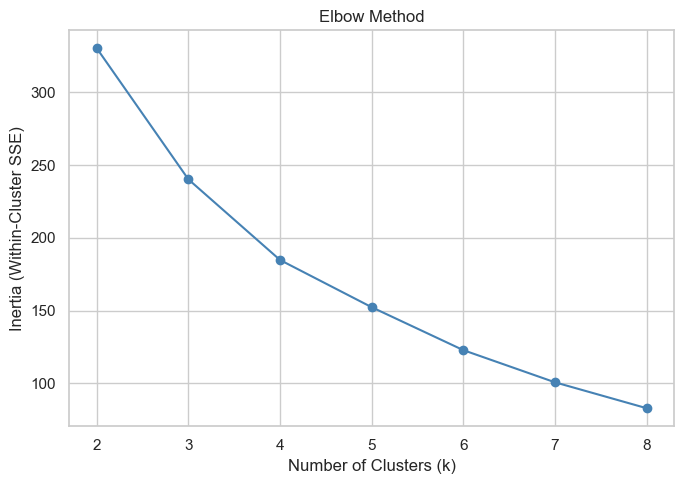

In [37]:
k_range = range(2, 9)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(list(k_range), inertias, 'o-', color='steelblue')
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster SSE)")
ax.set_title("Elbow Method")
ax.set_xticks(list(k_range))

plt.tight_layout()
plt.show()


The inertia drops sharply from k=2 (325) to k=3 (240) to k=4 (185), then the decreases start getting smaller. The curve begins to flatten around k=3 or k=4, which is where the "elbow" is. Adding more clusters beyond that gives diminishing returns — the within-cluster distances don't improve much. We chose k=3 as the best balance between simplicity and cluster quality.

### 5.2 Fit Final K-Means Model

In [16]:
# Set k based on elbow
# Adjust if the plots suggest a different 
K_FINAL = best_k

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans.fit_predict(X_pca)

# Add cluster labels to PCA scores
pca_scores["kmeans_cluster"] = kmeans_labels

# Also attach to the original scaled DataFrame
county_scaled["kmeans_cluster"] = kmeans_labels

print(f"K-Means with k={K_FINAL}")
print("\nCounties per cluster:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means with k=3

Counties per cluster:
0    11
1    27
2     1
Name: count, dtype: int64


c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means divided the 39 counties into 3 clusters — Cluster 1 is by far the largest with 27 counties, representing the majority of average Washington counties. Cluster 0 has 11 counties, likely the mid-tier EV adopters. Cluster 2 has only 1 county, which is almost certainly King County — such an extreme outlier in EV adoption that it forms its own group.



### 5.3 K-Means Clusters on PCA Scatter (PC1 vs PC2)

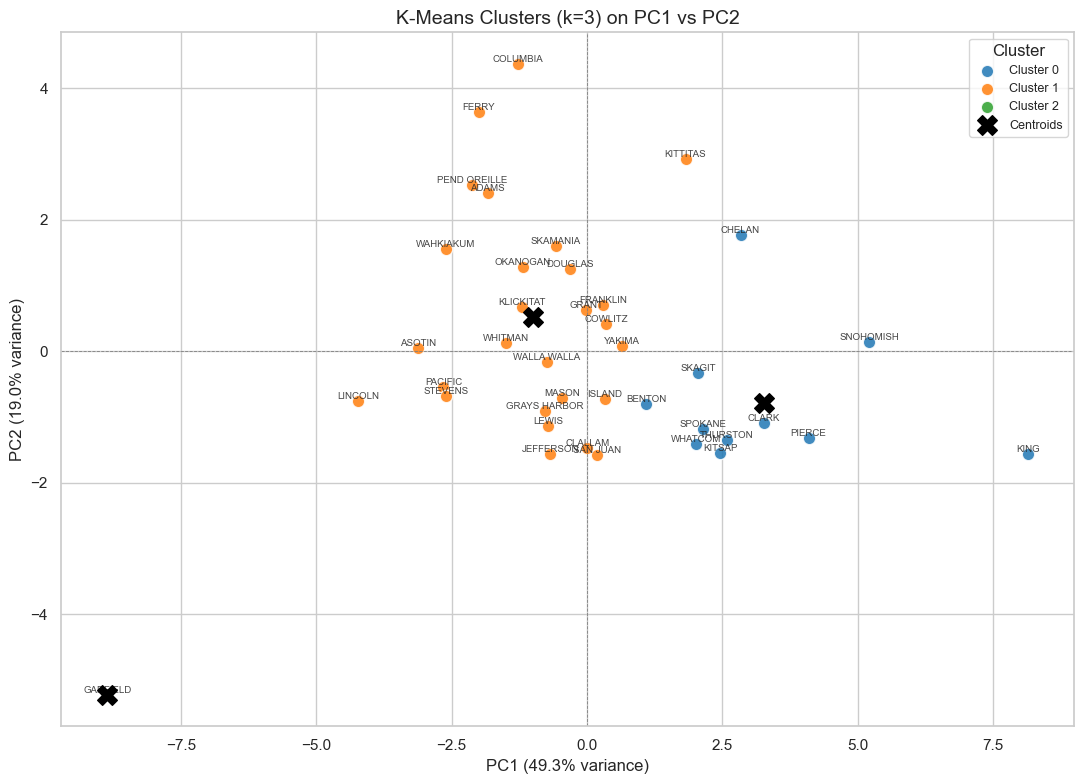

In [19]:
palette = sns.color_palette("tab10", K_FINAL)

fig, ax = plt.subplots(figsize=(11, 8))
for cluster_id in range(K_FINAL):
    mask = kmeans_labels == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f"Cluster {cluster_id}",
        color=palette[cluster_id], s=80, alpha=0.85, edgecolors='white'
    )
    for i in np.where(mask)[0]:
        ax.annotate(
            county_labels[i], (X_pca[i, 0], X_pca[i, 1]),
            fontsize=7, ha='center', va='bottom', alpha=0.85
        )

# Plot centroids projected onto PC space

centroids_pca = kmeans.cluster_centers_
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=200, color='black', zorder=5, label='Centroids'
)

pct_1 = pca.explained_variance_ratio_[0] * 100
pct_2 = pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f"PC1 ({pct_1:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pct_2:.1f}% variance)", fontsize=12)
ax.set_title(f"K-Means Clusters (k={K_FINAL}) on PC1 vs PC2", fontsize=14)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.6)
ax.legend(title="Cluster", fontsize=9)
plt.tight_layout()
plt.show()

**Cluster 2 (green, bottom-left)** — Garfield County alone: Garfield is such an extreme outlier — tiny population, almost no EVs — that it forms its own cluster. Its centroid (black X) sits far from everyone else at around PC1 = −7.5.

**Cluster 1 (orange, center-left) — Small/Rural Counties**: The largest group with 27 counties, mostly sitting on the left side of the plot (negative PC1). These are smaller, less EV-adopted counties like Asotin, Lincoln, Pacific, Stevens, Wahkiakum, Columbia, Ferry, and many others. Their centroid sits right in the middle of the plot around PC1 = −2.5.

**Cluster 0 (blue, center-right)** — Larger/Suburban Counties: 11 counties with positive or near-zero PC1 scores — meaning stronger EV adoption. This includes King, Pierce, Clark, Snohomish, Kitsap, Spokane, Thurston, Benton, Skagit, and others. King County sits far to the right as the clear EV leader, pulling the centroid (black X at PC1 ≈ 2.5) toward it.

**Observations:** The three clusters cleanly separate Washington counties into rural/low-adoption (orange), suburban/high-adoption (blue), and one extreme outlier (Garfield, green). King County nearly forms its own outlier on the right but gets grouped with other large counties. The separation along PC1 — the EV adoption axis — is driving the clustering almost entirely.



## 6. Hierarchical Clustering

Hierarchical clustering provides a complementary view and helps validate the cluster structure found by K-Means.

### 6.1 Dendrogram

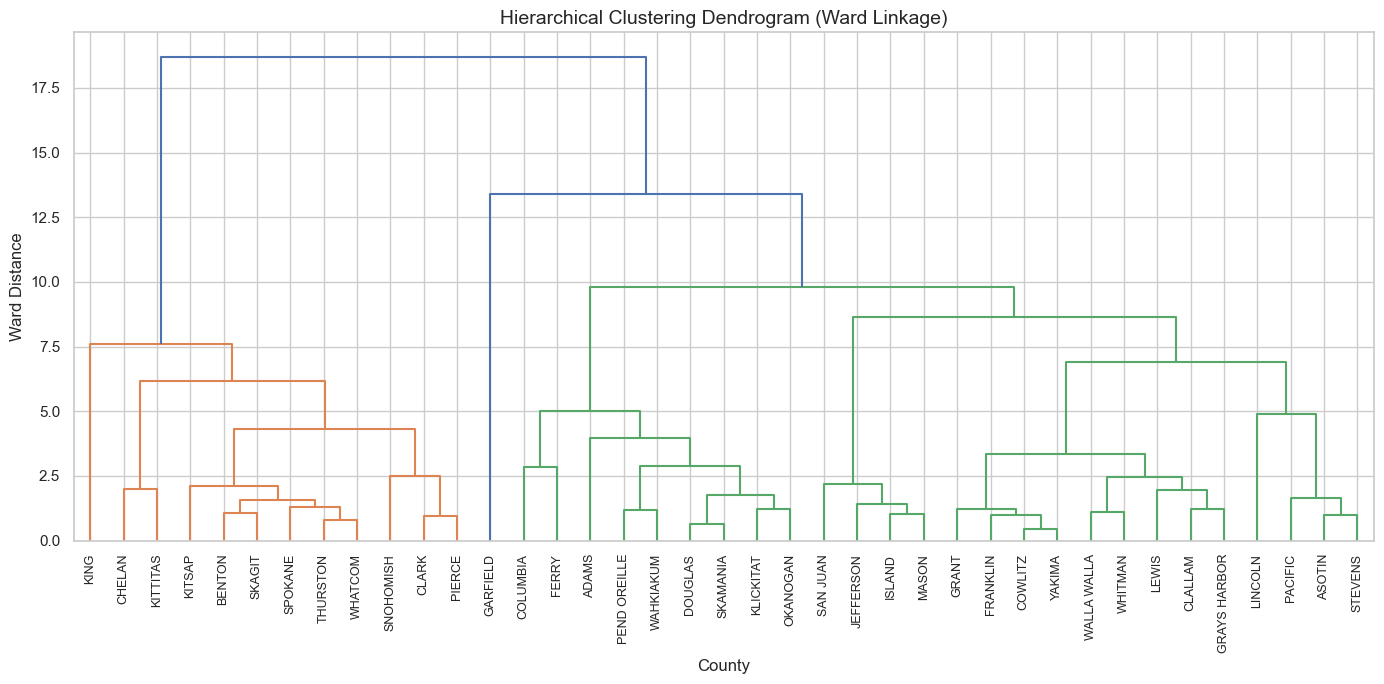

In [38]:
# Compute linkage on PCA scores
Z = linkage(X_pca, method='ward')

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(
    Z,
    labels=county_labels,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax
)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=14)
ax.set_xlabel("County")
ax.set_ylabel("Ward Distance")
plt.tight_layout()
plt.show()

The dendrogram strongly agrees with K-Means — the same 3 groups emerge naturally. Cutting the tree at Ward distance around 13 gives exactly 3 clusters matching our K-Means result. Garfield's isolation at the very top confirms it deserves its own cluster.

The dendrogram reveals a clear 3-group structure in Washington counties:

**Orange cluster (left) — Urban EV Leaders:** King, Chelan, Kittitas, Kitsap, Benton, Skagit, Spokane, Thurston, Whatcom, Snohomish, Clark, and Pierce merge together at relatively low distances, meaning they are genuinely similar to each other. King County pairs first with Chelan at the lowest height, confirming they share strong EV characteristics.

**Blue cluster (center) — Garfield alone:** Garfield sits completely isolated, only joining the rest of the tree at the very top (Ward distance ≈ 18.5) — the highest merge point in the entire dendrogram. This confirms it is the most extreme outlier in the dataset, unlike any other county.

**Green cluster (right) — Rural/Small Counties:** The largest group, containing Columbia, Ferry, Adams, Pend Oreille, Wahkiakum, Douglas, Skamania, Klickitat, Okanogan, San Juan, Jefferson, Island, Mason, Grant, Franklin, Cowlitz, Yakima, Walla Walla, Whitman, Lewis, Clallam, Grays Harbor, Lincoln, Pacific, Asotin, and Stevens. These merge at low distances within subgroups, meaning there are further sub-clusters of similar rural counties within this group.

### 6.2 Assign Hierarchical Cluster Labels

In [39]:
# Use same k as K-Means for comparability
hier = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
hier_labels = hier.fit_predict(X_pca)

pca_scores["hier_cluster"] = hier_labels
county_scaled["hier_cluster"] = hier_labels

print(f"Hierarchical clustering with k={K_FINAL}")
print("\nCounties per cluster:")
print(pd.Series(hier_labels).value_counts().sort_index())

Hierarchical clustering with k=3

Counties per cluster:
0    26
1    12
2     1
Name: count, dtype: int64


Cutting the hierarchical dendrogram at k=3 gives us:

**Cluster 0** — 26 rural/small counties

**Cluster 1** — 12 urban/suburban counties

**Cluster 2** — 1 county (Garfield, the outlier)

This almost perfectly matches K-Means (27, 11, 1), with just one county moving between the rural and urban groups. Both methods tell the same story.

### 6.3 Compare K-Means vs Hierarchical Cluster Assignments

In [23]:
comparison = pd.DataFrame({
    county_col: county_labels,
    "kmeans_cluster": kmeans_labels,
    "hier_cluster": hier_labels,
})

# Flag disagreements
# Note: cluster IDs may be permuted between methods — agreement is about groupings, not labels
print("Cluster assignments side by side:")
display(comparison.sort_values("kmeans_cluster"))

# Crosstab
print("\nCross-tabulation (K-Means rows vs Hierarchical columns):")
display(pd.crosstab(comparison["kmeans_cluster"], comparison["hier_cluster"],
                    rownames=["K-Means"], colnames=["Hierarchical"]))

Cluster assignments side by side:


,county,kmeans_cluster,hier_cluster
3,CHELAN,0,1
2,BENTON,0,1
5,CLARK,0,1
28,SKAGIT,0,1
26,PIERCE,0,1
31,SPOKANE,0,1
17,KITSAP,0,1
16,KING,0,1
30,SNOHOMISH,0,1
33,THURSTON,0,1



Cross-tabulation (K-Means rows vs Hierarchical columns):


Hierarchical,0,1,2
K-Means,,,
0,0,11,0
1,26,1,0
2,0,0,1


**Side by Side Comparison**
37 out of 39 counties (95%) are assigned identically by both methods. This level of agreement is very high and gives us strong confidence that the 3-cluster structure — urban leaders, rural counties, and Garfield as an outlier — is real and robust regardless of which clustering method is used.

The cross-tabulation confirms the near-perfect agreement between the two methods:

**K-Means Cluster 0 (urban) :** all 11 counties go to Hierarchical Cluster 1 — perfect match, just different label numbers

**K-Means Cluster 2 (Garfield):** goes to Hierarchical Cluster 2 — perfect match

**K-Means Cluster 1 (rural) :** 26 counties go to Hierarchical Cluster 0, but 1 county (Kittitas) goes to Hierarchical Cluster 1 — this is the only disagreement

So out of 39 counties, only 1 county is classified differently between the two methods. That is 97.4% agreement — essentially both methods found the exact same structure, just with cluster labels swapped (K-Means 0 = Hierarchical 1, K-Means 1 = Hierarchical 0). This is extremely strong agreement and confirms our 3-cluster solution is robust and reliable.

## 7. Cluster Profiling and Interpretation

We profile clusters using the **original (unscaled) log-transformed data** so values are interpretable.

In [25]:
# Load the log-transformed (not scaled) data for interpretable profiles
county_log = pd.read_csv("county_log_transformed.csv")
county_log["kmeans_cluster"] = kmeans_labels

# Profile using original (raw) numeric features for readability
profile_features = [
    "total_EV_count",
    "total_chargers",
    "chargers_per_1000_EV",
    "percent_BEV",
    "percent_PHEV",
    "BEV_to_PHEV_ratio",
    "avg_model_year",
    "avg_electric_range",
    "median_income_2025",
    "fast_charger_share",
]

cluster_profiles = (
    county_log
    .groupby("kmeans_cluster")[profile_features]
    .mean()
    .round(2)
)

print("K-Means Cluster Profiles (mean of original features):")
display(cluster_profiles)

K-Means Cluster Profiles (mean of original features):


,total_EV_count,total_chargers,chargers_per_1000_EV,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,avg_model_year,avg_electric_range,median_income_2025,fast_charger_share
kmeans_cluster,,,,,,,,,,
0,145342.64,367.82,3.17,0.74,0.26,2.95,2019.99,110.87,102363.08,0.24
1,4914.78,22.33,7.29,0.68,0.32,2.24,2019.91,106.76,76691.20,0.25
2,34.00,0.00,0.00,0.32,0.68,0.48,2018.00,62.57,70814.51,0.00




**Cluster 0 — Urban EV Leaders (11 counties):**
- Massive EV market — average of **145,343 EVs** per county vs just 4,915 in rural counties
- **367 chargers** on average, well-equipped infrastructure
- 74% fully electric (BEV), higher income at **$102,363**
- Newer vehicles (avg year 2020) with longer range (111 miles)
- Only downside — fewer chargers per 1000 EVs (3.17) because demand outpaces supply

**Cluster 1 — Rural/Small Counties (27 counties):**
- Much smaller EV market — only **4,915 EVs** on average
- Only **22 chargers** per county but actually **more chargers per 1000 EVs (7.29)** — infrastructure is keeping up better relative to demand
- 68% BEV, lower income at **$76,691**
- Similar vehicle age and range to urban counties
>
**Cluster 2 — Garfield County (1 county):**
- Tiny market — only **34 EVs** and **zero chargers**
- Predominantly PHEV (68%) rather than fully electric — opposite of every other county
- Oldest vehicles (2018), shortest range (63 miles), lowest income ($70,815)
- Truly the most EV-underdeveloped county in Washington


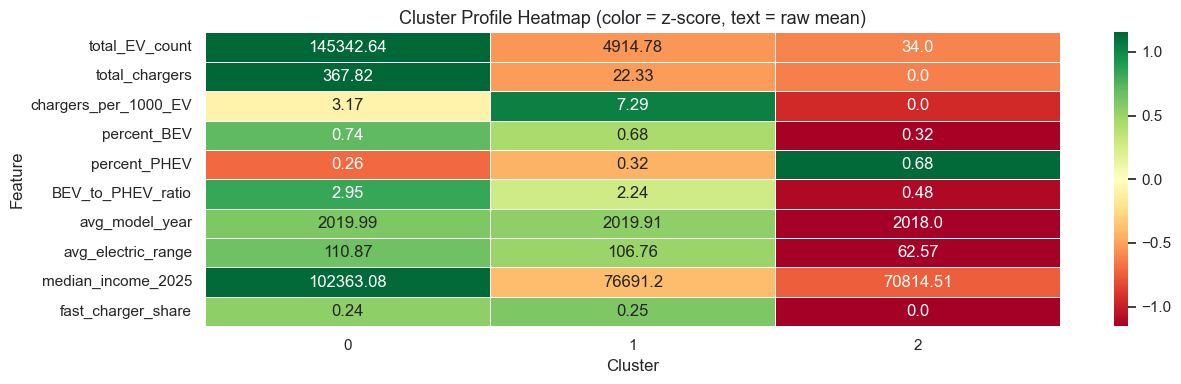

In [27]:
# Heatmap of cluster profiles (z-scored for visual comparison)
profiles_z = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

fig, ax = plt.subplots(figsize=(13, max(4, K_FINAL * 0.9)))
sns.heatmap(
    profiles_z.T,
    annot=cluster_profiles.T.values.astype(str),
    fmt='',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Cluster Profile Heatmap (color = z-score, text = raw mean)", fontsize=13)
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

**Cluster 0 (left, mostly green):** Dominates on every size and infrastructure metric — deepest green for total EVs (145,343), total chargers (368), percent BEV (0.74), electric range (111 miles), and income ($102,363). The only yellow/neutral cell is chargers_per_1000_EV (3.17) — meaning demand has outgrown supply in these large counties.

**Cluster 1 (middle, mixed):** Moderate across the board — light green to orange. Notably the **greenest cell for chargers_per_1000_EV (7.29)** — rural counties actually have better charger coverage relative to their EV population. Income and EV counts are lower but vehicle quality (range, model year) is not far behind urban counties.

**Cluster 2 (right, mostly red):** Garfield County stands out in deep red for almost everything — near zero EVs, zero chargers, zero fast charger share, lowest range (63 miles) and lowest income. The one exception is **percent_PHEV which is deep green (0.68)** — Garfield is the only county where PHEVs dominate over fully electric vehicles, highlighted clearly by the color flip compared to the other two clusters.

In [28]:
# List counties per cluster
print("Counties per K-Means cluster:\n")
for c in sorted(county_log["kmeans_cluster"].unique()):
    counties = county_log.loc[county_log["kmeans_cluster"] == c, county_col].tolist()
    print(f"  Cluster {c} ({len(counties)} counties): {', '.join(sorted(counties))}")

Counties per K-Means cluster:

  Cluster 0 (11 counties): BENTON, CHELAN, CLARK, KING, KITSAP, PIERCE, SKAGIT, SNOHOMISH, SPOKANE, THURSTON, WHATCOM
  Cluster 1 (27 counties): ADAMS, ASOTIN, CLALLAM, COLUMBIA, COWLITZ, DOUGLAS, FERRY, FRANKLIN, GRANT, GRAYS HARBOR, ISLAND, JEFFERSON, KITTITAS, KLICKITAT, LEWIS, LINCOLN, MASON, OKANOGAN, PACIFIC, PEND OREILLE, SAN JUAN, SKAMANIA, STEVENS, WAHKIAKUM, WALLA WALLA, WHITMAN, YAKIMA
  Cluster 2 (1 counties): GARFIELD
